In [ ]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset,DataLoader
from PIL import Image
import torchvision.transforms as transforms
import torch.nn as nn
from collections import OrderedDict
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
%matplotlib inline

In [ ]:
import os
import csv

assigned_label = 0
train_root = '/kaggle/input/cattledata/Data/USData'
test_root = '/kaggle/input/cattledata/Data/UNEData'

# Get the list of cattle names (subdirectories)
train_cattle = next(os.walk(train_root))[1]
test_cattle = next(os.walk(test_root))[1]

# Writing training data
with open('cattle_train_data.csv', 'w', newline='') as csvfile:
    fields = ['ID', 'Path', 'Label']
    csvwriter = csv.writer(csvfile, delimiter=',')
    csvwriter.writerow(fields)

    for cattle_name in train_cattle:
        for image in os.listdir(os.path.join(train_root, cattle_name)):
            label = assigned_label
            path = os.path.join(train_root, cattle_name, image)
            csvwriter.writerow([image, path, str(label)])
        assigned_label += 1

# Reset the label for test data
assigned_label = 0

# Writing test data
with open('cattle_test_data.csv', 'w', newline='') as csvfile:
    fields = ['ID', 'Path', 'Label']
    csvwriter = csv.writer(csvfile, delimiter=',')
    csvwriter.writerow(fields)

    for cattle_name in test_cattle:
        for image in os.listdir(os.path.join(test_root, cattle_name)):
            label = assigned_label
            path = os.path.join(test_root, cattle_name, image)
            csvwriter.writerow([image, path, str(label)])
        assigned_label += 1


In [ ]:
trainframe=pd.read_csv("/kaggle/working/cattle_train_data.csv")
testframe=pd.read_csv("/kaggle/working/cattle_test_data.csv")

In [ ]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [ ]:
class Task(object):
  def __init__(self,all_classes,num_classes,num_instances):
    self.all_classes=all_classes
    self.num_classes=num_classes
    self.num_instances=num_instances
    self.train_roots=[]
    self.meta_roots=[]
    self.train_labels=[]
    self.meta_labels=[]
    samples_per_class=4
    sampled_classes=random.sample(all_classes,num_classes)
    label=0
    #labels=list(range(len(sampled_classes)))

    for c in sampled_classes:
      cframe=trainframe.iloc[(c*samples_per_class):((c+1)*samples_per_class)]
      cframe.reset_index(inplace=True,drop=True)
      paths=cframe["Path"]
      sample_idxs=np.random.choice(samples_per_class,samples_per_class,replace=False)
      train_idxs=sample_idxs[:num_instances]
      meta_idxs=sample_idxs[num_instances:(num_instances*2)]
      for idx in train_idxs:
        self.train_roots.append(paths[idx])
        self.train_labels.append(label)
      for idx in meta_idxs:
        self.meta_roots.append(paths[idx])
        self.meta_labels.append(label)
      label+=1

class TestTask(object):
  def __init__(self,all_classes,num_classes,num_instances,num_test_instances):
    self.all_classes=all_classes
    self.num_classes=num_classes
    self.num_instances=num_instances
    self.num_test_instances=num_test_instances
    self.test_roots=[]
    self.train_roots=[]
    self.test_labels=[]
    self.train_labels=[]
    samples_per_class=4
    sampled_classes=random.sample(all_classes,num_classes)
    label=0
    #labels=list(range(len(sampled_classes)))

    for c in sampled_classes:
      #cframe=testframe.iloc[((c-964)*samples_per_class):(((c+1)-964)*samples_per_class)]
      cframe=testframe.iloc[((c-268)*samples_per_class):(((c+1)-268)*samples_per_class)]
      cframe.reset_index(inplace=True,drop=True)
      paths=cframe["Path"]
      sample_idxs=np.random.choice(samples_per_class,samples_per_class,replace=False)
      train_idxs=sample_idxs[:num_instances]
      test_idxs=sample_idxs[num_instances:(num_instances+num_test_instances)]
      for idx in test_idxs:
        self.test_roots.append(paths[idx])
        self.test_labels.append(label)
      # for idx in meta_idxs:
      #   self.meta_roots.append(paths[idx])
      #   self.meta_labels.append(label)
      for idx in train_idxs:
        self.train_roots.append(paths[idx])
        self.train_labels.append(label)
      label+=1

In [ ]:
class MiniSet(Dataset):
  def __init__(self,fileroots,labels,transform):
    self.fileroots=fileroots
    self.labels=labels
    self.transform=transform

  def __len__(self):
    return len(self.fileroots)

  def __getitem__(self,idx):
    img=Image.open(self.fileroots[idx])
    img=self.transform(img)
    return img,self.labels[idx]

In [ ]:
transform=transforms.Compose([transforms.Resize((224,224)),transforms.ToTensor()])
def get_loaders(task):
  loaders={}
  train_fileroots=task.train_roots
  train_labels=task.train_labels
  meta_fileroots=task.meta_roots
  meta_labels=task.meta_labels
  trainloader=DataLoader(MiniSet(train_fileroots,train_labels,transform),
                         batch_size=len(train_fileroots),shuffle=True)
  metaloader=DataLoader(MiniSet(meta_fileroots,meta_labels,transform),
                         batch_size=len(meta_fileroots),shuffle=True)
  #print((len(trainloader)))
  #print((len(metaloader)))
  loaders["train"]=trainloader
  loaders["meta"]=metaloader
  return loaders

def get_test_loaders(task):
  loaders={}
  test_fileroots=task.test_roots
  test_labels=task.test_labels
  train_fileroots=task.train_roots
  train_labels=task.train_labels
  testloader=DataLoader(MiniSet(test_fileroots,test_labels,transform),
                         batch_size=len(test_fileroots),shuffle=True)
  # metaloader=DataLoader(MiniSet(meta_fileroots,meta_labels,transform),
  #                        batch_size=len(meta_fileroots),shuffle=True)
  trainloader=DataLoader(MiniSet(train_fileroots,train_labels,transform),
                         batch_size=len(train_fileroots),shuffle=True)
  loaders["train"]=trainloader
  #loaders["meta"]=metaloader
  loaders["test"]=testloader
  return loaders

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import OrderedDict
from transformers import ViTModel

# Define the BaseNet model
class BaseNet(nn.Module):
    def __init__(self, num_classes):
        super(BaseNet, self).__init__()

        # Load pre-trained ResNet50 and remove the last layer
        model_Res = torch.hub.load('pytorch/vision:v0.10.0', 'resnet50', pretrained=True)
        layers_Res = list(model_Res.children())
        self.resnet = nn.Sequential(*layers_Res[:-1])  # Remove the classification layer

        # Freeze selective layers in ResNet
        for name, param in self.resnet.named_parameters():
            if name.startswith('7.') or name.startswith('6.') or name.startswith('5.'):
                param.requires_grad = False
            else:
                param.requires_grad = True

        # Load pre-trained Vision Transformer (ViT) and remove the last layers
        model_trans = ViTModel.from_pretrained('google/vit-base-patch16-224-in21k')
        layers_trans = list(model_trans.children())
        self.vit = nn.Sequential(*layers_trans[:-2])  # Remove the final classification layers

        # Freeze selective layers in ViT
        for name, param in self.vit.named_parameters():
            if name.startswith("0.") or name.startswith("1.layer.3") or name.startswith("1.layer.4") or \
               name.startswith("1.layer.5") or name.startswith("1.layer.6") or name.startswith("1.layer.7") or \
               name.startswith("1.layer.8") or name.startswith("1.layer.9") or name.startswith("1.layer.10") or \
               name.startswith("1.layer.11"):
                param.requires_grad = True
            else:
                param.requires_grad = False

        # Define additional layers for feature fusion and classification
        self.res_linear = nn.Linear(2048, 64)
        self.trans_linear = nn.Linear(768, 64)
        self.self_attention = nn.MultiheadAttention(embed_dim=64, num_heads=8)
        self.fc = nn.Linear(64, num_classes)

    def forward(self, trans_b, res_b, weights=None):
        # ResNet Path
        if weights is None:
            res_features = self.resnet(res_b)
            res_features = torch.flatten(res_features, 1)
            res_features = self.res_linear(res_features)
        else:
            res_features = F.conv2d(
                res_b, weights['resnet.0.weight'], weights['resnet.0.bias'], stride=2, padding=3
            )
            res_features = torch.flatten(res_features, 1)
            res_features = F.linear(res_features, weights['res_linear.weight'], weights['res_linear.bias'])

        # Vision Transformer Path
        if weights is None:
            vit_features = self.vit(trans_b).last_hidden_state
            vit_features = torch.mean(vit_features, dim=1)  # Pooling
            vit_features = self.trans_linear(vit_features)
        else:
            vit_features = F.linear(
                trans_b.view(trans_b.size(0), -1),
                weights['trans_linear.weight'],
                weights['trans_linear.bias']
            )

        # Feature Fusion with Self-Attention
        res_features = res_features.unsqueeze(0)  # Add sequence dimension
        vit_features = vit_features.unsqueeze(0)
        fused_features, _ = self.self_attention(vit_features, res_features, vit_features)
        fused_features = fused_features.squeeze(0)  # Remove sequence dimension

        # Classification
        if weights is None:
            out = self.fc(fused_features)
        else:
            out = F.linear(fused_features, weights['fc.weight'], weights['fc.bias'])

        return out


In [ ]:
class MetaLearner(nn.Module):
    def __init__(self, num_classes):
        super(MetaLearner, self).__init__()
        self.meta_learner = BaseNet(num_classes)

        # Define CNN-based co-learner for 3-channel images
        self.co_learner = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),  # 3 channels for input images
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),  # Aggregate spatial dimensions
            nn.Flatten(),
            nn.Linear(32, 64),  # Match the output size with the feature extractor (64 channels)
            nn.ReLU(),
            nn.Linear(64, num_classes)  # Output size matches the final layer of BaseNet
        )

    def forward(self, x, mod_weights=None):
        if mod_weights is None:
            out = self.meta_learner(x)
        else:
            out = self.meta_learner(x, mod_weights)
        return out

    def clone_state_dict(self):
        cloned_state_dict = {key: val.clone() for key, val in self.state_dict().items()}
        return cloned_state_dict

    def augment_gradients(self, gradients):
        # Reshape gradients for CNN processing
        reshaped_gradients = torch.stack([g.view(-1, 3, int(g.size(0) ** 0.5), int(g.size(0) ** 0.5)) for g in gradients])
        augmented_output = self.co_learner(reshaped_gradients)

        # Return augmented gradients split back into original parameter sizes
        return augmented_output.split([p.numel() for p in self.meta_learner.parameters()])


In [ ]:
def train_single_task(net,lr,loaders,num_updates,loss_metric):
  net.train()
  trainloader=loaders["train"]
  #x,y=trainloader.__iter__().next()
  data_iterator = iter(trainloader)
  x, y = next(data_iterator)
  x.to(device)
  y.to(device)
  output=net(x)
  loss=loss_metric(output,y)

  def zero_grad(params):
    for p in params:
      if p.grad is not None:
        p.grad.zero_()
  zero_grad(net.parameters())
  grads=torch.autograd.grad(loss,net.parameters(),create_graph=True)
  mod_state_dict=net.clone_state_dict()
  mod_weights=OrderedDict()
  for (k,v),g in zip(net.named_parameters(),grads):
    mod_weights[k]=v-lr*g
    mod_state_dict[k]=mod_weights[k]
  for i in range(1,num_updates):
    output=net(x,mod_state_dict)
    loss=loss_metric(output,y)
    zero_grad(mod_weights.values())
    grads=torch.autograd.grad(loss,mod_weights.values(),create_graph=True)
    for (k,v),g in zip(mod_weights.items(),grads):
      mod_weights[k]=v-lr*g
      mod_state_dict[k]=mod_weights[k]

  return mod_state_dict

In [ ]:
def train(
    net,
    meta_train_classes,
    meta_optimizer,
    co_optimizer,
    loss_metric,
    num_classes,
    num_instances,
    num_tasks,
    lr,
    meta_lr,
    num_inner_updates,
    num_epochs,
    lambda_co
):
    total_loss = 0
    print_every = 1
    plot_every = 1
    meta_losses = []

    for epoch in range(1, num_epochs + 1):
        state_dicts = []
        loaders_list = []

        # Inner-loop task adaptation
        for n in range(num_tasks):
            task = Task(meta_train_classes, num_classes, num_instances)
            loaders = get_loaders(task)
            d = train_single_task(net, lr, loaders, num_inner_updates, loss_metric)
            state_dicts.append(d)
            loaders_list.append(loaders)

        metaloss = 0
        coloss = 0  # Initialize co-learner loss
        for n in range(num_tasks):
            loaders = loaders_list[n]
            metaloader = loaders["meta"]
            data_iterator1 = iter(metaloader)
            x, y = next(data_iterator1)
            x = x.to(device)
            y = y.to(device)

            d = state_dicts[n]
            output = net(x, d)
            loss = loss_metric(output, y)
            metaloss += loss

            # Co-learner regularization
            meta_gradients = torch.autograd.grad(loss, net.meta_learner.parameters(), retain_graph=True)
            augmented_gradients = torch.autograd.grad(loss, net.parameters(), retain_graph=True)
            co_loss = torch.norm(
                torch.cat([g.view(-1) for g in meta_gradients]) -
                torch.cat([g.view(-1) for g in augmented_gradients])
            )
            coloss += co_loss

        # Compute average loss across tasks
        metaloss /= float(num_tasks)
        coloss /= float(num_tasks)

        # Integrated loss
        total_loss = metaloss + lambda_co * coloss

        # Meta-learner optimization
        meta_optimizer.zero_grad()
        total_loss.backward(retain_graph=True)  # Retain the graph for co-learner
        meta_optimizer.step()

        # Co-learner optimization
        co_optimizer.zero_grad()
        coloss.backward()  # Update co-learner gradients only
        co_optimizer.step()

        # Logging and metrics
        if epoch % print_every == 0:
            print(f"{epoch}/{num_epochs}. meta_loss: {metaloss.item()}, co_loss: {coloss.item()}, total_loss: {total_loss.item()}")

        if epoch % plot_every == 0:
            meta_losses.append(total_loss.item())

        if epoch % 10 == 0:
            print(f"Epoch {epoch} completed.")

    return meta_losses, net


In [ ]:

loss_metric=nn.CrossEntropyLoss()
num_classes=5
net=MetaLearner(num_classes)
lr=1e-1
meta_lr=1e-3
meta_optimizer = torch.optim.Adam(net.parameters(), lr=meta_lr,weight_decay=1e-5)
co_optimizer = torch.optim.Adam(net.co_learner.parameters(), lr=meta_lr, weight_decay=1e-5)
num_instances=1
num_tasks=10
num_inner_updates=1
num_epochs=500
train_classes=np.max(trainframe['Label'])
train_classes=list(np.arange(train_classes))
metalosses,net=train(net,train_classes,meta_optimizer,co_optimizer,loss_metric,num_classes,num_instances,num_tasks,lr,meta_lr,num_inner_updates,num_epochs,lambda_co=0.10)

1/500. loss: 1.1125109195709229
Epoch 1 completed.
2/500. loss: 1.093597412109375
Epoch 2 completed.
3/500. loss: 1.1190464496612549
Epoch 3 completed.
4/500. loss: 1.0435659885406494
Epoch 4 completed.
5/500. loss: 1.1522562503814697
Epoch 5 completed.
6/500. loss: 1.0471762418746948
Epoch 6 completed.
7/500. loss: 1.1107304096221924
Epoch 7 completed.
8/500. loss: 1.0367884635925293
Epoch 8 completed.
9/500. loss: 1.0328402519226074
Epoch 9 completed.
10/500. loss: 1.0041706562042236
Epoch 10 completed.
11/500. loss: 0.9458234906196594
Epoch 11 completed.
12/500. loss: 1.0251312255859375
Epoch 12 completed.
13/500. loss: 0.9051653742790222
Epoch 13 completed.
14/500. loss: 0.8567376136779785
Epoch 14 completed.
15/500. loss: 0.8614095449447632
Epoch 15 completed.
16/500. loss: 1.025328278541565
Epoch 16 completed.
17/500. loss: 0.9141898155212402
Epoch 17 completed.
18/500. loss: 0.9315893054008484
Epoch 18 completed.
19/500. loss: 0.9239047765731812
Epoch 19 completed.
20/500. loss:

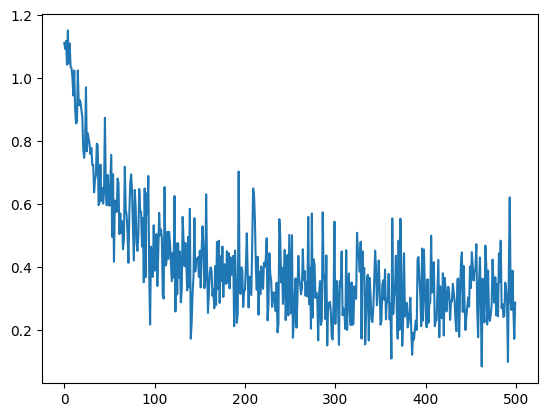

In [ ]:
plt.plot(metalosses)

In [ ]:
def accuracy(outputs, labels):
  outputs = np.argmax(outputs, axis=1)
  return np.sum(outputs == labels) / float(labels.size)


In [ ]:
def evaluate(net,test_classes,task_lr,num_classes=5,num_steps=100,num_eval_updates=3):
  #net.eval()
  losses=[]
  acc_list=[]
  for step in np.arange(num_steps):
    task=TestTask(test_classes,num_classes=5,num_instances=4,num_test_instances=3)
    loaders=get_test_loaders(task)
    trainloader,testloader=loaders["train"],loaders["test"]
    #x_train,y_train=trainloader.__iter__().next()
    data_iterator3 = iter(trainloader)
    x_train, y_train = next(data_iterator3)
    x_train.to(device)
    y_train.to(device)
    #x_test,y_test=testloader.__iter__().next()
    data_iterator4 = iter(testloader)
    x_test, y_test = next(data_iterator4)

    x_train.to(device)
    y_train.to(device)
    x_test.to(device)
    y_test.to(device)
    #def __init__(self,all_classes,num_classes,num_instances,num_test_instances)
    cloned_net=copy.deepcopy(net)
    optim = torch.optim.SGD(cloned_net.parameters(),lr=task_lr)
    for _ in range(num_eval_updates):
      y_train_pred=cloned_net(x_train)
      loss=loss_metric(y_train_pred,y_train)
      optim.zero_grad()
      loss.backward()
      optim.step()
    y_test_pred=cloned_net(x_test)
    loss=loss_metric(y_test_pred,y_test)
    losses.append(loss)
    y_test_pred=y_test_pred.data.cpu().numpy()
    y_test=y_test.data.cpu().numpy()
    #print(y_test)
    #print(y_test_pred)
    acc=accuracy(y_test_pred,y_test)
    acc_list.append(acc)
  return acc_list,losses


In [ ]:
import copy
import numpy as np
import torch
#test_classes=np.max(testframe['Label'])-np.min(testframe['Label'])
test_classes=list(np.arange(np.min(testframe['Label']),np.max(testframe['Label']+1)))
acc_list,losses=evaluate(net,test_classes,task_lr=1e-1)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(net, test_classes, task_lr, num_classes=5, num_steps=100, num_eval_updates=3, device='cuda'):
    losses = []
    acc_list = []
    precision_list = []
    recall_list = []
    f1_list = []

    net.to(device)  # Ensure the original network is on the correct device

    for step in np.arange(num_steps):
        task = TestTask(test_classes, num_classes=num_classes, num_instances=4, num_test_instances=3)
        loaders = get_test_loaders(task)
        trainloader, testloader = loaders["train"], loaders["test"]

        data_iterator3 = iter(trainloader)
        x_train, y_train = next(data_iterator3)
        x_train, y_train = x_train.to(device), y_train.to(device)

        data_iterator4 = iter(testloader)
        x_test, y_test = next(data_iterator4)
        x_test, y_test = x_test.to(device), y_test.to(device)

        cloned_net = copy.deepcopy(net).to(device)  # Move the cloned network to the correct device
        optim = torch.optim.SGD(cloned_net.parameters(), lr=task_lr)

        for _ in range(num_eval_updates):
            y_train_pred = cloned_net(x_train)
            loss = loss_metric(y_train_pred, y_train)
            optim.zero_grad()
            loss.backward()
            optim.step()

        y_test_pred = cloned_net(x_test)
        loss = loss_metric(y_test_pred, y_test)
        losses.append(loss.item())  # Ensure loss is converted to a scalar

        y_test_pred = torch.argmax(y_test_pred, dim=1).cpu().numpy()
        y_test = y_test.cpu().numpy()

        # Calculate accuracy, precision, recall, and F1 score
        acc = accuracy_score(y_test, y_test_pred)
        precision = precision_score(y_test, y_test_pred, average='weighted')
        recall = recall_score(y_test, y_test_pred, average='weighted')
        f1 = f1_score(y_test, y_test_pred, average='weighted')

        acc_list.append(acc)
        precision_list.append(precision)
        recall_list.append(recall)
        f1_list.append(f1)

    return acc_list, precision_list, recall_list, f1_list, losses


In [ ]:
# Assuming 'net' is your model, 'test_classes' are your test classes, and 'device' is either 'cuda' or 'cpu'
acc_list, precision_list, recall_list, f1_list, losses = evaluate(net, test_classes, task_lr=1e-1, device='cuda')

print(f"Accuracy: {np.mean(acc_list)}")
print(f"Precision: {np.mean(precision_list)}")
print(f"Recall: {np.mean(recall_list)}")
print(f"F1 Score: {np.mean(f1_list)}")



Accuracy: 0.972685
Precision: 0.956
Recall: 0.984
F1 Score: 0.969798
